## ***Анализ дисбаланса классов для cirrhosis_preprocessed***


Целевая переменная: Status


## Что будет сделано

1. Посмотрим на исходное распределение классов в сыром датасете.
2. Разделим данные на train и test.
3. Выполним балансировку Random under-sampling только на train, чтобы не загрязнять тестовую выборку.
4. Построим матрицу корреляций для нового мини-датасета.
5. По boxplot найдем и удалим выбросы по наиболее информативным признакам.
6. Сравним пространство признаков до и после балансировки через понижение размерности и кластеризацию.


In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from imblearn.under_sampling import RandomUnderSampler

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42
TARGET = "Status"
CLASS_ORDER = [0, 1, 2]
CLASS_PALETTE = {
    0: "#1f77b4",
    1: "#ff7f0e",
    2: "#2ca02c",
}

data_path = Path("../cirrhosis_preprocessed.csv")
if not data_path.exists():
    data_path = Path("cirrhosis_preprocessed.csv")

def make_countplot(ax, series, title):
    counts = series.value_counts().sort_index()
    labels = [int(x) for x in counts.index.tolist()]
    colors = [CLASS_PALETTE.get(label, "#999999") for label in labels]

    ax.bar(labels, counts.values, color=colors, edgecolor="black", alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel(TARGET)
    ax.set_ylabel("Количество объектов")
    ax.set_xticks(labels)

    offset = max(counts.values) * 0.02 if len(counts) else 0.0
    for x_pos, y_pos in zip(labels, counts.values):
        ax.text(x_pos, y_pos + offset, str(int(y_pos)), ha="center", fontsize=10)

def scatter_by_class(ax, embedding, y, title):
    y_array = np.asarray(y)
    for cls in sorted(np.unique(y_array)):
        mask = y_array == cls
        ax.scatter(
            embedding[mask, 0],
            embedding[mask, 1],
            s=45,
            alpha=0.82,
            color=CLASS_PALETTE.get(int(cls), "#999999"),
            label=f"Класс {int(cls)}",
        )
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend()

def fit_linear_test_embeddings(train_X_df, test_X_df):
    train_values = train_X_df.values
    test_values = test_X_df.values

    pca = PCA(n_components=2)
    pca_train = pca.fit_transform(train_values)
    pca_test = pca.transform(test_values)

    svd = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
    svd_train = svd.fit_transform(train_values)
    svd_test = svd.transform(test_values)

    return {
        "PCA": {"train": pca_train, "test": pca_test},
        "TruncatedSVD": {"train": svd_train, "test": svd_test},
    }

def build_joint_tsne_embedding(train_X_df, test_X_df):
    combined = pd.concat(
        [
            train_X_df.reset_index(drop=True),
            test_X_df.reset_index(drop=True),
        ],
        axis=0,
    )
    train_size = len(train_X_df)
    perplexity = min(30, max(5, min(len(combined) - 1, len(combined) // 3)))

    embedding = TSNE(
        n_components=2,
        random_state=RANDOM_STATE,
        init="pca",
        learning_rate="auto",
        perplexity=perplexity,
    ).fit_transform(combined.values)

    return {
        "train": embedding[:train_size],
        "test": embedding[train_size:],
    }

def evaluate_test_clustering(train_embedding, test_embedding, y_train, y_test, stage, method):
    y_train_array = np.asarray(y_train)
    y_test_array = np.asarray(y_test)

    model = KMeans(
        n_clusters=len(np.unique(y_train_array)),
        n_init=20,
        random_state=RANDOM_STATE,
    )
    model.fit(train_embedding)
    test_clusters = model.predict(test_embedding)

    silhouette = np.nan
    if len(np.unique(test_clusters)) > 1 and len(test_embedding) > len(np.unique(test_clusters)):
        silhouette = round(silhouette_score(test_embedding, test_clusters), 3)

    return {
        "Сценарий": stage,
        "Метод": method,
        "Объектов на графике": len(test_embedding),
        "ARI test vs Status": round(adjusted_rand_score(y_test_array, test_clusters), 3),
        "Silhouette test": silhouette,
    }

def remove_iqr_outliers_per_class(df_in, target_col, features):
    cleaned = df_in.copy()
    report_rows = []

    for feature in features:
        drop_idx = []
        for cls in sorted(cleaned[target_col].unique()):
            class_values = cleaned.loc[cleaned[target_col] == cls, feature]
            q1, q3 = class_values.quantile([0.25, 0.75])
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr

            current_idx = cleaned[
                (cleaned[target_col] == cls)
                & ((cleaned[feature] < lower) | (cleaned[feature] > upper))
            ].index

            report_rows.append(
                {
                    "feature": feature,
                    "class": int(cls),
                    "q1": round(float(q1), 3),
                    "q3": round(float(q3), 3),
                    "lower_bound": round(float(lower), 3),
                    "upper_bound": round(float(upper), 3),
                    "removed_points": int(len(current_idx)),
                }
            )
            drop_idx.extend(current_idx.tolist())

        cleaned = cleaned.drop(index=pd.Index(drop_idx).unique())

    report = pd.DataFrame(report_rows)
    return cleaned.reset_index(drop=True), report


## Загрузка данных

Для задачи дисбаланса будем использовать Status как целевой признак.
Идентификатор ID в моделирование включать не будем, потому что он не несет полезной информации о классе.


In [2]:
df = pd.read_csv(data_path)
df[TARGET] = df[TARGET].astype(int)

display(df.head())
print(f"Размер датасета: {df.shape[0]} строк x {df.shape[1]} столбцов")
print(f"Всего пропусков: {int(df.isna().sum().sum())}")
print(f"Типы классов в {TARGET}: {sorted(df[TARGET].unique().tolist())}")


,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,...,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Age_years
0,1,400,2,0.0,21464,0.0,1.0,1.0,1.0,2.0,...,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0,58.805479
1,2,4500,0,0.0,20617,0.0,0.0,1.0,1.0,0.0,...,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0,56.484932
2,3,1012,2,0.0,25594,1.0,0.0,0.0,0.0,1.0,...,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0,70.120548
3,4,1925,2,0.0,19994,0.0,0.0,1.0,1.0,1.0,...,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0,54.778082
4,5,1504,1,1.0,13918,0.0,0.0,1.0,1.0,0.0,...,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0,38.131507


Размер датасета: 312 строк x 21 столбцов
Всего пропусков: 0
Типы классов в Status: [0, 1, 2]


## 1. Изначальное распределение классов

Сначала посмотрим на классический источник проблемы: насколько сильно исходный датасет смещен в сторону одного или нескольких классов.


,count,share_%
Status,,
0,168,53.85
1,19,6.09
2,125,40.06


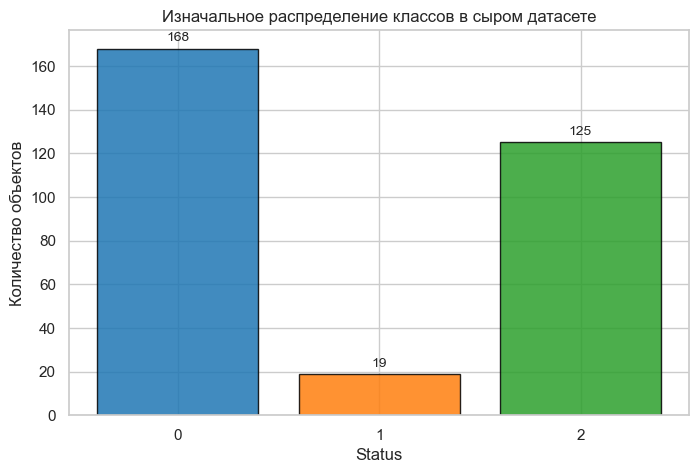

Самый редкий класс: 1. Его доля всего 6.09% — дисбаланс достаточно выраженный.


In [3]:
raw_distribution = pd.DataFrame(
    {
        "count": df[TARGET].value_counts().sort_index(),
        "share_%": (df[TARGET].value_counts(normalize=True).sort_index() * 100).round(2),
    }
)
display(raw_distribution)

fig, ax = plt.subplots(figsize=(8, 5))
make_countplot(ax, df[TARGET], "Изначальное распределение классов в сыром датасете")
plt.show()

minority_class = int(raw_distribution["count"].idxmin())
minority_share = raw_distribution.loc[minority_class, "share_%"]
print(
    f"Самый редкий класс: {minority_class}. Его доля всего {minority_share}% — "
    "дисбаланс достаточно выраженный."
)


## 2. Разделение на train и test + масштабирование признаков

Как и в примере, масштабирование нужно делать только после разделения данных.
Здесь используется RobustScaler, потому что он устойчивее к выбросам.


In [4]:
X = df.drop(columns=["ID", TARGET]).copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

scaler = RobustScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
).reset_index(drop=True)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
).reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

train_distribution = pd.DataFrame(
    {
        "count": y_train.value_counts().sort_index(),
        "share_%": (y_train.value_counts(normalize=True).sort_index() * 100).round(2),
    }
)
test_distribution = pd.DataFrame(
    {
        "count": y_test.value_counts().sort_index(),
        "share_%": (y_test.value_counts(normalize=True).sort_index() * 100).round(2),
    }
)

display(pd.concat({"train": train_distribution, "test": test_distribution}, axis=1))
print(f"Размер train: {X_train_scaled.shape}, размер test: {X_test_scaled.shape}")
print("Тестовая выборка осталась нетронутой: дальше балансируем только train.")


train          test        
       count share_% count share_%
Status                            
0        134   53.82    34   53.97
1         15    6.02     4    6.35
2        100   40.16    25   39.68

Размер train: (249, 19), размер test: (63, 19)
Тестовая выборка осталась нетронутой: дальше балансируем только train.


## 3. Балансировка с помощью Random under-sampling

Создаем новый мини-датасет из train, случайно уменьшая размеры доминирующих классов до уровня самого редкого класса.


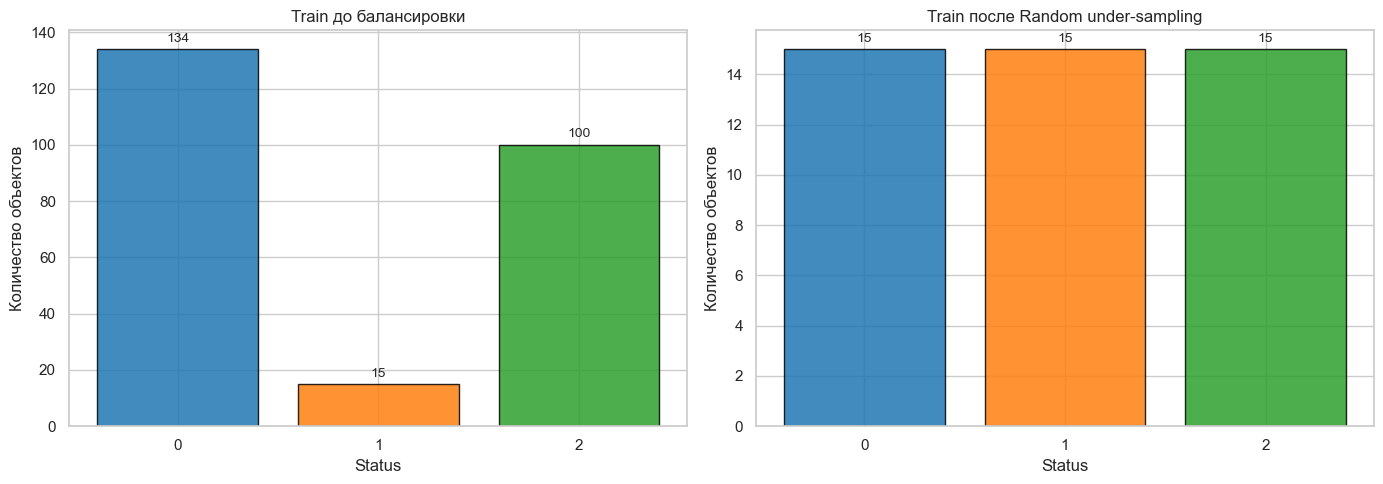

,train_before,train_after
Status,,
0,134,15
1,15,15
2,100,15


После балансировки train уменьшился с 249 до 45 объектов, но классы стали симметричными.


In [5]:
rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_train_balanced, y_train_balanced = rus.fit_resample(X_train_scaled, y_train)

balanced_train_df = X_train_balanced.copy()
balanced_train_df[TARGET] = y_train_balanced.values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
make_countplot(axes[0], y_train, "Train до балансировки")
make_countplot(axes[1], balanced_train_df[TARGET], "Train после Random under-sampling")
plt.tight_layout()
plt.show()

comparison_distribution = pd.DataFrame(
    {
        "train_before": y_train.value_counts().sort_index(),
        "train_after": balanced_train_df[TARGET].value_counts().sort_index(),
    }
).fillna(0).astype(int)
display(comparison_distribution)

print(
    f"После балансировки train уменьшился с {len(y_train)} до {len(y_train_balanced)} объектов, "
    "но классы стали симметричными."
)


## 4. Матрица корреляций для мини-датасета

После балансировки связи с целевой переменной становятся менее смазанными, потому что редкий класс больше не подавлен большим числом объектов.


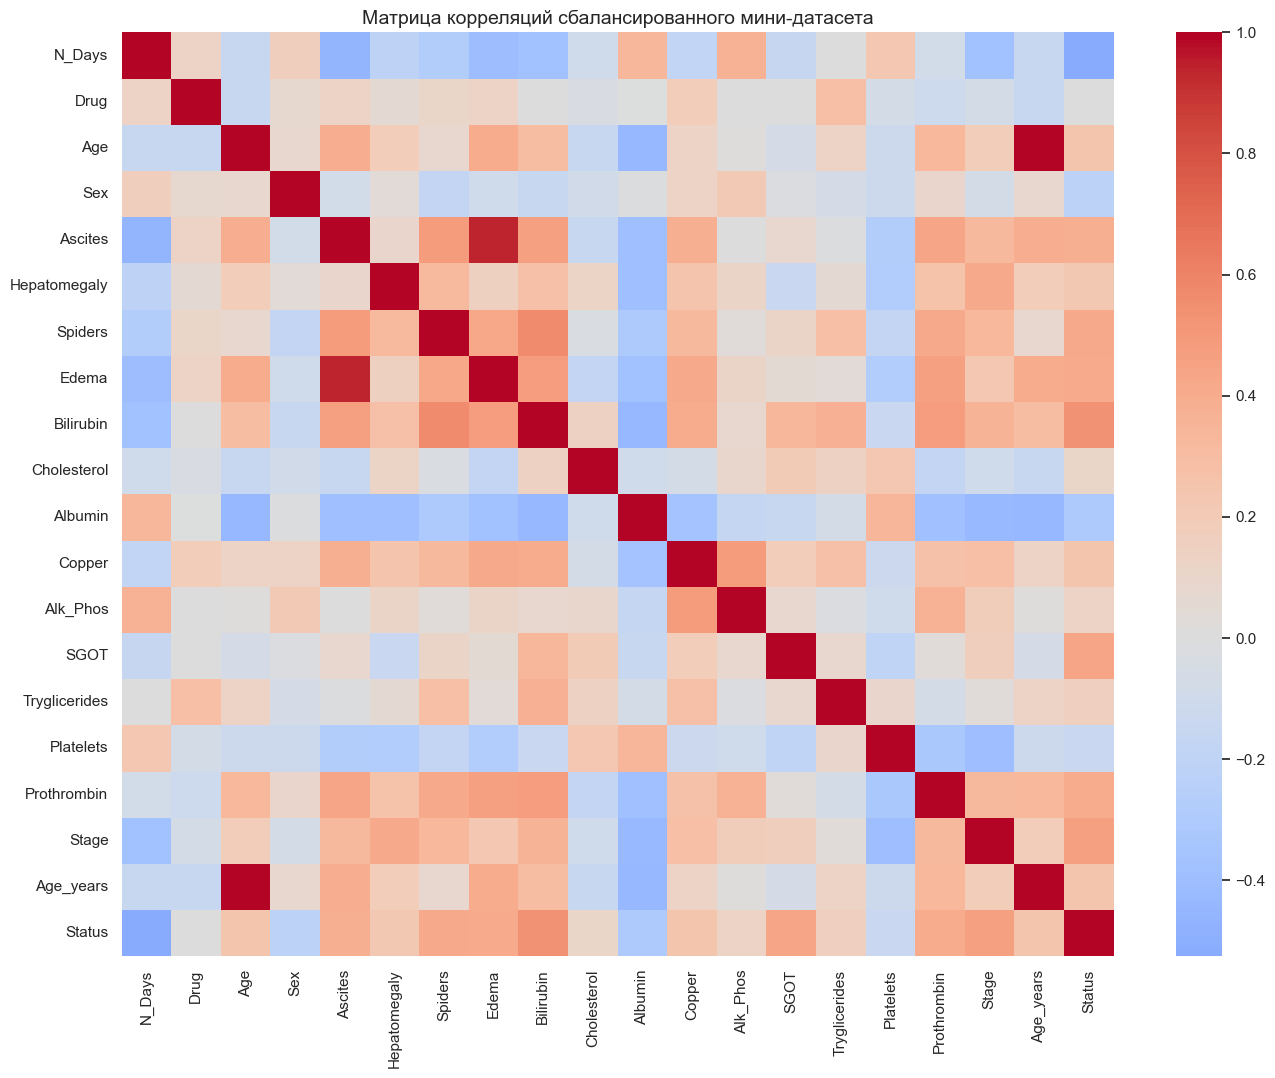

,corr_with_Status
Bilirubin,0.529784
N_Days,-0.525375
Stage,0.467477
SGOT,0.436973
Spiders,0.420336
Edema,0.413675
Prothrombin,0.398427
Ascites,0.382546
Albumin,-0.309451
Copper,0.247366


Признаки для boxplot и удаления выбросов: Bilirubin, N_Days, SGOT, Prothrombin


In [6]:
corr_matrix = balanced_train_df.corr(numeric_only=True)
corr_with_target = corr_matrix[TARGET].drop(TARGET).sort_values(
    key=lambda s: s.abs(),
    ascending=False,
)

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Матрица корреляций сбалансированного мини-датасета", fontsize=14)
plt.show()

display(corr_with_target.to_frame("corr_with_Status").head(10))

continuous_features = [
    col for col in X_train_scaled.columns
    if balanced_train_df[col].nunique() > 10
]
top_features = (
    corr_with_target[corr_with_target.index.isin(continuous_features)]
    .abs()
    .sort_values(ascending=False)
    .head(4)
    .index
    .tolist()
)

print("Признаки для boxplot и удаления выбросов:", ", ".join(top_features))


## 5. Boxplot и удаление выбросов

Ниже строятся boxplot по четырем наиболее связанным с Status непрерывным признакам.
Затем выбросы удаляются по правилу IQR отдельно внутри каждого класса


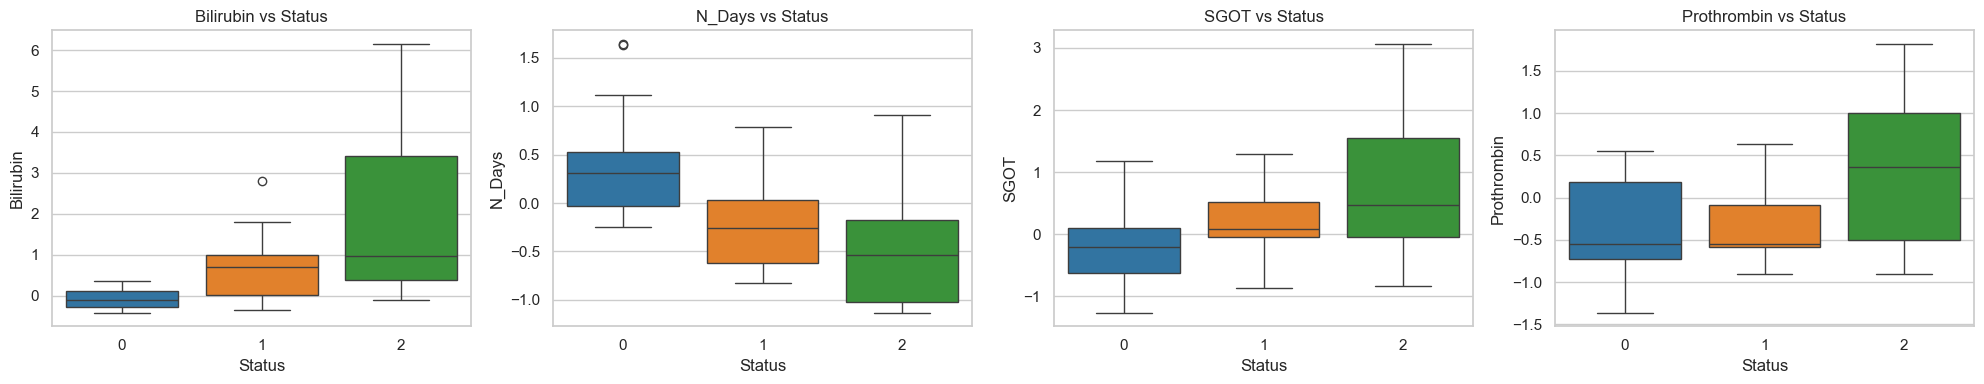

На boxplot хорошо видны экстремальные точки. Удалять будем только по наиболее информативным признакам, как и в блокноте-примере.


In [7]:
fig, axes = plt.subplots(1, len(top_features), figsize=(5 * len(top_features), 4))
axes = np.atleast_1d(axes)
box_palette = [CLASS_PALETTE[idx] for idx in CLASS_ORDER]

for ax, feature in zip(axes, top_features):
    sns.boxplot(
        data=balanced_train_df,
        x=TARGET,
        y=feature,
        order=CLASS_ORDER,
        palette=box_palette,
        ax=ax,
    )
    ax.set_title(f"{feature} vs Status")

plt.tight_layout()
plt.show()

print(
    "На boxplot хорошо видны экстремальные точки. Удалять будем только по наиболее информативным признакам, "
    "как и в блокноте-примере."
)


In [8]:
balanced_train_clean_df, outlier_report = remove_iqr_outliers_per_class(
    balanced_train_df,
    TARGET,
    top_features,
)

display(outlier_report)
display(
    outlier_report.groupby("feature", as_index=False)["removed_points"].sum()
    .rename(columns={"removed_points": "total_removed"})
)

clean_distribution = pd.DataFrame(
    {
        "count": balanced_train_clean_df[TARGET].value_counts().sort_index(),
        "share_%": (
            balanced_train_clean_df[TARGET].value_counts(normalize=True).sort_index() * 100
        ).round(2),
    }
)

display(clean_distribution)
print(
    f"После удаления выбросов осталось {len(balanced_train_clean_df)} объектов "
    f"из {len(balanced_train_df)} в мини-датасете."
)


,feature,class,q1,q3,lower_bound,upper_bound,removed_points
0,Bilirubin,0,-0.288,0.115,-0.894,0.721,0
1,Bilirubin,1,0.019,0.981,-1.423,2.423,1
2,Bilirubin,2,0.385,3.423,-4.173,7.981,0
3,N_Days,0,-0.034,0.529,-0.879,1.374,2
4,N_Days,1,-0.627,0.138,-1.775,1.287,0
5,N_Days,2,-1.020,-0.177,-2.284,1.088,0
6,SGOT,0,-0.622,0.089,-1.689,1.156,1
7,SGOT,1,-0.056,0.528,-0.932,1.404,0
8,SGOT,2,-0.040,1.550,-2.425,3.935,0
9,Prothrombin,0,-0.841,0.000,-2.102,1.261,0


,feature,total_removed
0,Bilirubin,1
1,N_Days,2
2,Prothrombin,0
3,SGOT,1


,count,share_%
Status,,
0,12,29.27
1,14,34.15
2,15,36.59


После удаления выбросов осталось 41 объектов из 45 в мини-датасете.


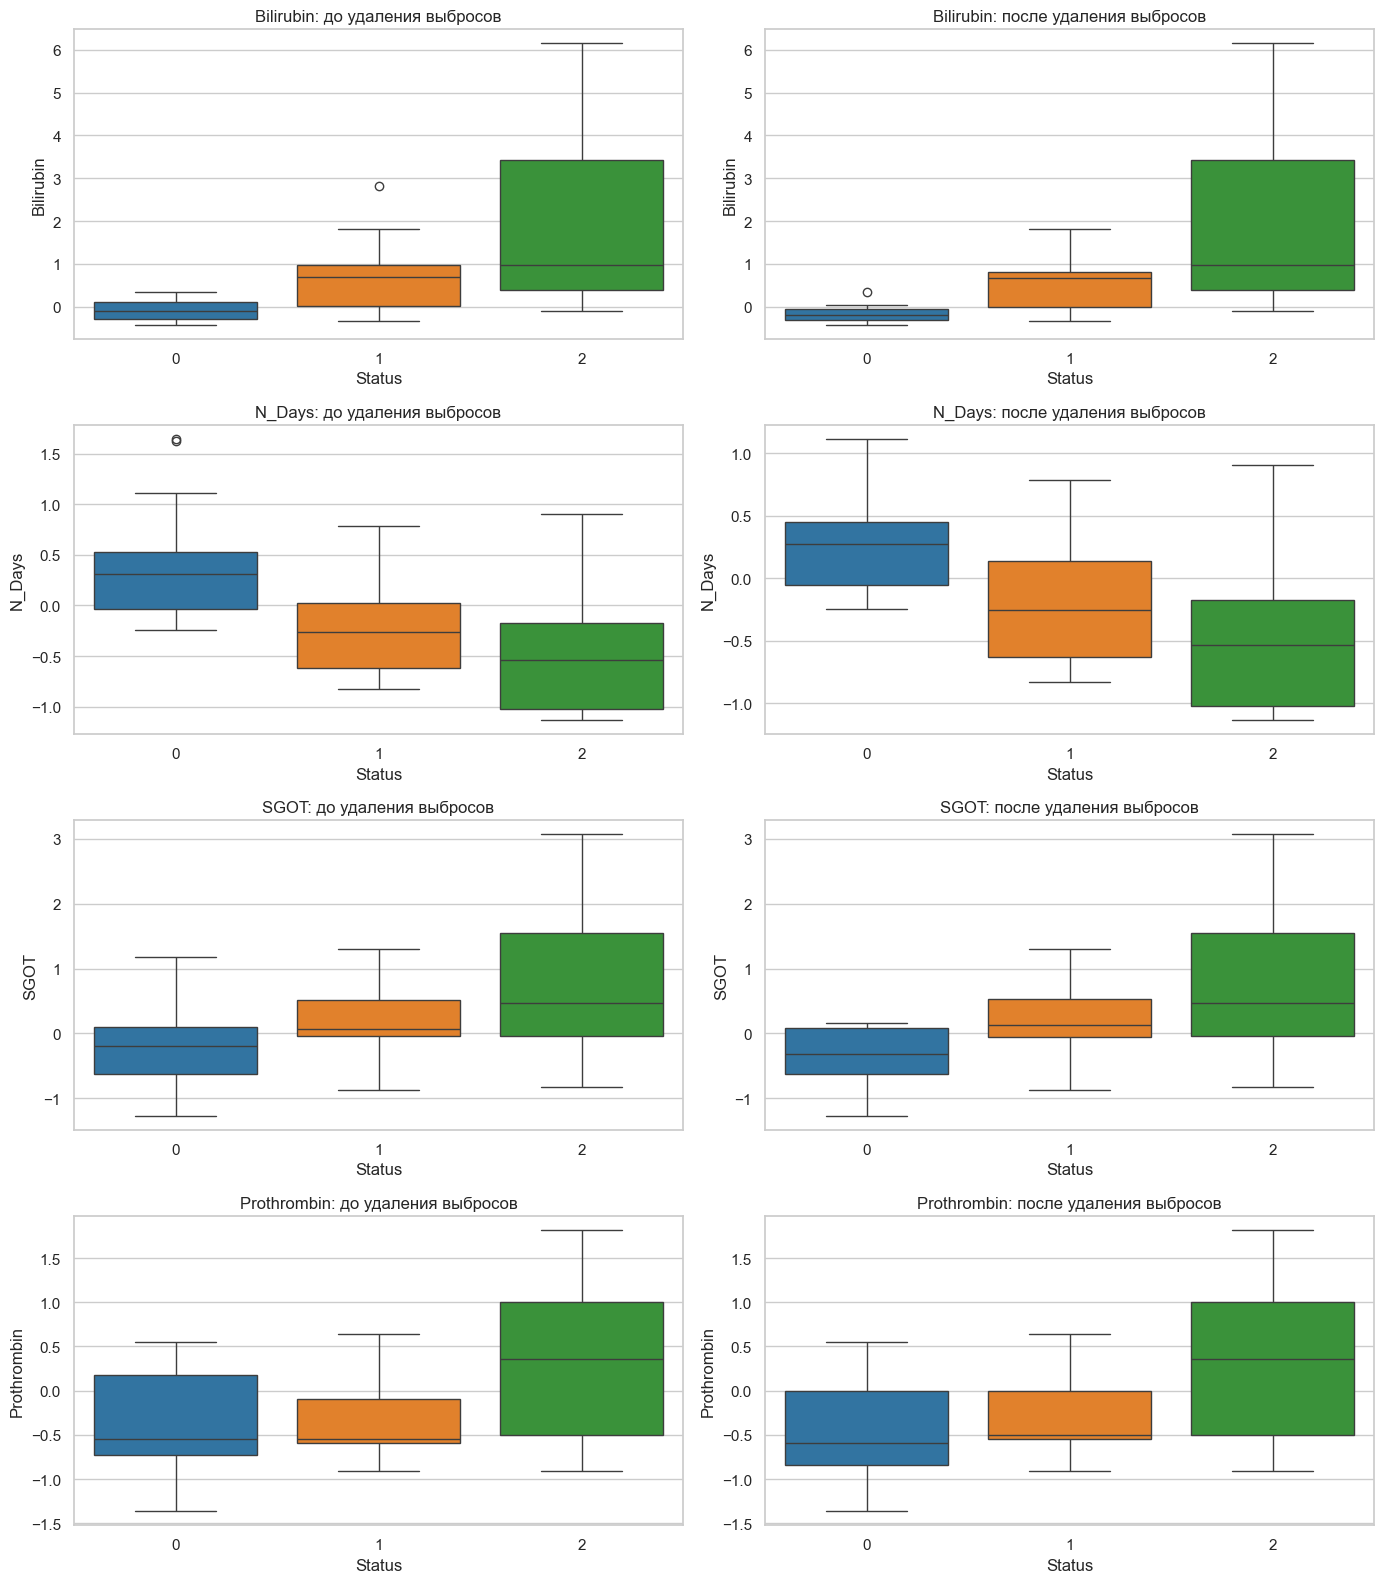

После очистки распределения стали компактнее: крайние точки заметно сократились.


In [9]:
fig, axes = plt.subplots(len(top_features), 2, figsize=(14, 4 * len(top_features)))

for row_idx, feature in enumerate(top_features):
    sns.boxplot(
        data=balanced_train_df,
        x=TARGET,
        y=feature,
        order=CLASS_ORDER,
        palette=box_palette,
        ax=axes[row_idx, 0],
    )
    axes[row_idx, 0].set_title(f"{feature}: до удаления выбросов")

    sns.boxplot(
        data=balanced_train_clean_df,
        x=TARGET,
        y=feature,
        order=CLASS_ORDER,
        palette=box_palette,
        ax=axes[row_idx, 1],
    )
    axes[row_idx, 1].set_title(f"{feature}: после удаления выбросов")

plt.tight_layout()
plt.show()

print("После очистки распределения стали компактнее: крайние точки заметно сократились.")


## 6. Понижение размерности и кластеризация на test-части исходного датасета

- `До`: методы понижения размерности и кластеризации опираются на исходный `train`.
- `После`: те же методы опираются на `balanced + clean train`.
- На графиках в обоих случаях отображаются **только объекты test**.

Важное замечание:

- Для `PCA` и `TruncatedSVD` test-выборка проецируется через преобразования, обученные на соответствующем `train`.
- Для `t-SNE` в `scikit-learn` нет отдельного `transform`, поэтому embedding строится на объединении `train + test`, но на график выводится только тестовая часть. За счет этого число объектов для сравнения остается одинаковым.


,Сценарий,Объектов на графиках
0,До балансировки,63
1,После балансировки и очистки,63


Во всех проекциях ниже отображается один и тот же test-набор из 63 объектов.


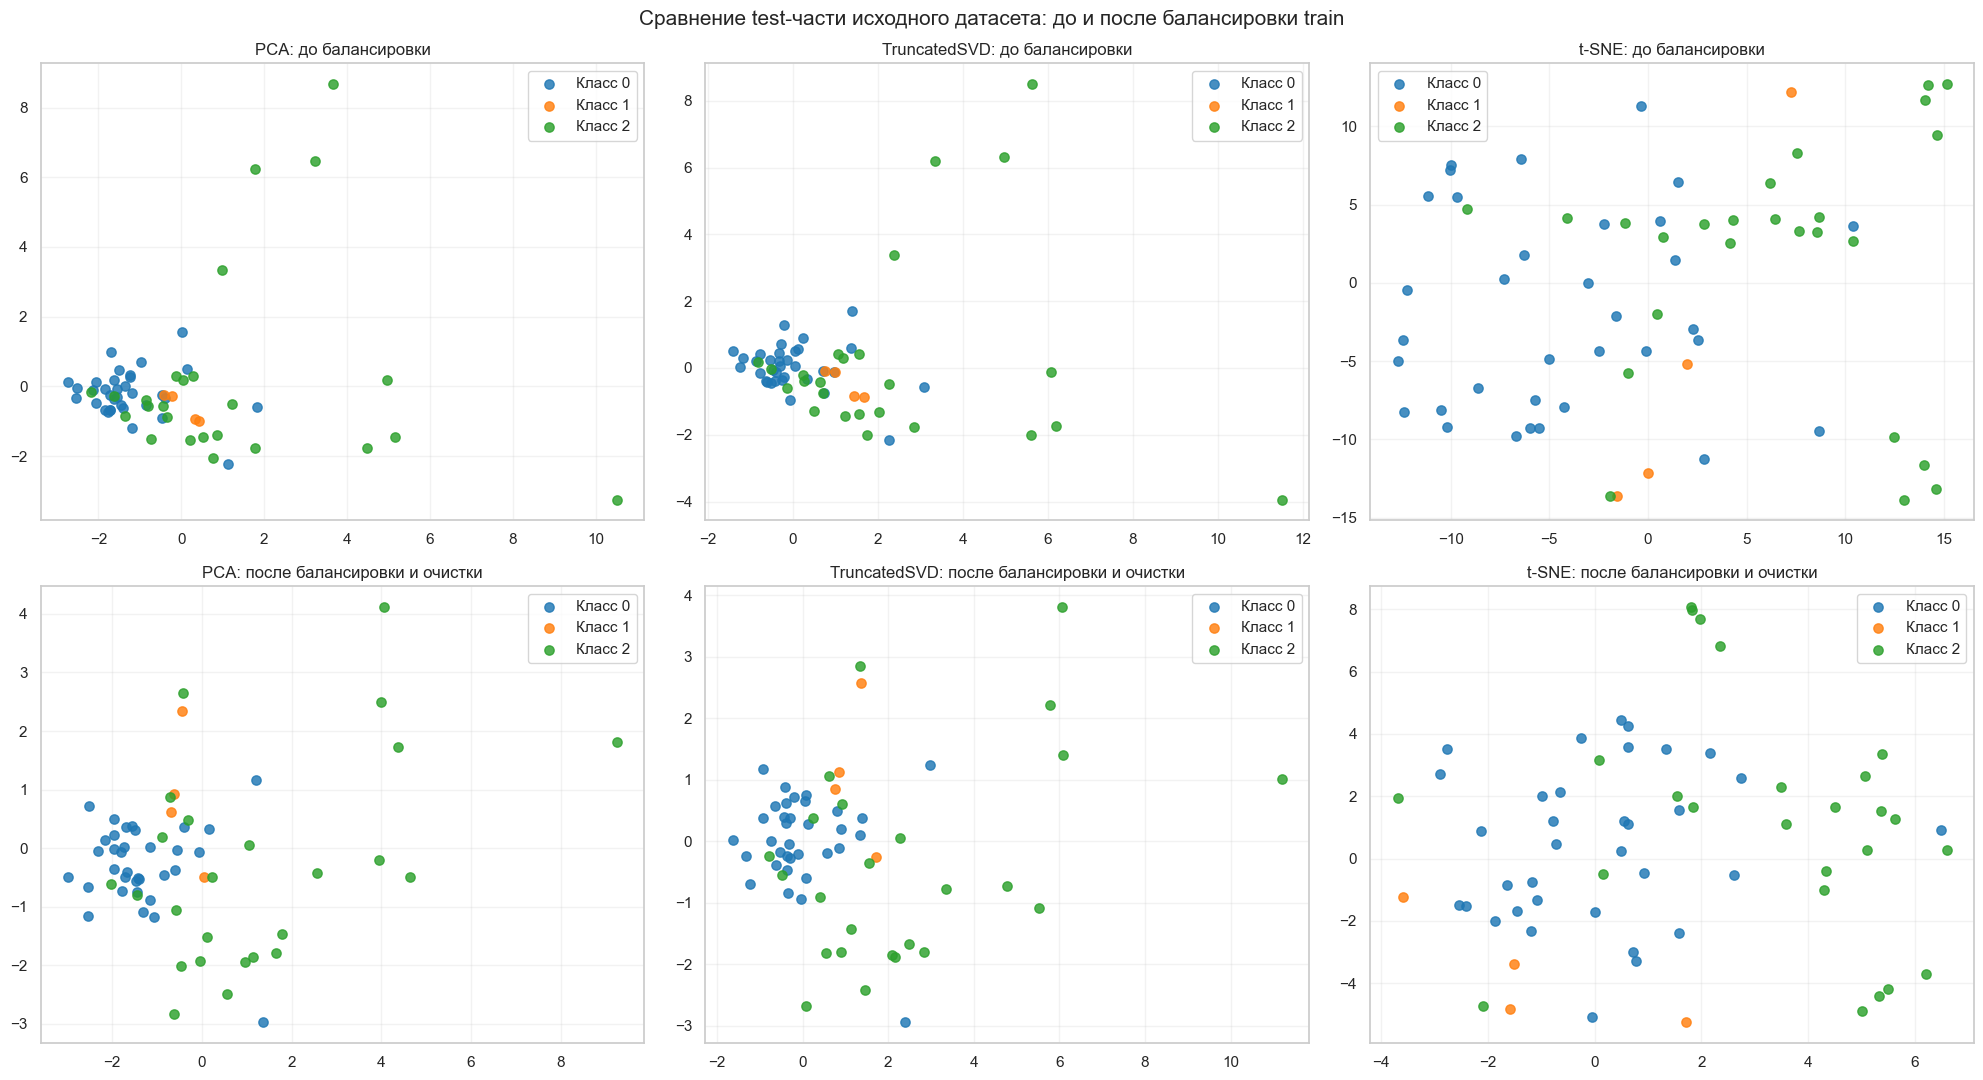

In [10]:
raw_train_features = X_train_scaled.reset_index(drop=True).copy()
raw_test_features = X_test_scaled.reset_index(drop=True).copy()
raw_train_target = y_train.reset_index(drop=True).copy()
raw_test_target = y_test.reset_index(drop=True).copy()

balanced_clean_train_features = balanced_train_clean_df.drop(columns=[TARGET]).reset_index(drop=True).copy()
balanced_clean_train_target = balanced_train_clean_df[TARGET].reset_index(drop=True).copy()

test_compare_sets = {
    "До балансировки": {
        "train_X": raw_train_features,
        "train_y": raw_train_target,
        "test_X": raw_test_features,
        "test_y": raw_test_target,
    },
    "После балансировки и очистки": {
        "train_X": balanced_clean_train_features,
        "train_y": balanced_clean_train_target,
        "test_X": raw_test_features,
        "test_y": raw_test_target,
    },
}

embeddings_by_stage = {}
metrics_rows = []
methods = ["PCA", "TruncatedSVD", "t-SNE"]

for stage_name, cfg in test_compare_sets.items():
    linear_embeddings = fit_linear_test_embeddings(cfg["train_X"], cfg["test_X"])
    tsne_embeddings = build_joint_tsne_embedding(cfg["train_X"], cfg["test_X"])

    stage_train_embeddings = {
        "PCA": linear_embeddings["PCA"]["train"],
        "TruncatedSVD": linear_embeddings["TruncatedSVD"]["train"],
        "t-SNE": tsne_embeddings["train"],
    }
    stage_test_embeddings = {
        "PCA": linear_embeddings["PCA"]["test"],
        "TruncatedSVD": linear_embeddings["TruncatedSVD"]["test"],
        "t-SNE": tsne_embeddings["test"],
    }

    embeddings_by_stage[stage_name] = stage_test_embeddings

    for method in methods:
        metrics_rows.append(
            evaluate_test_clustering(
                stage_train_embeddings[method],
                stage_test_embeddings[method],
                cfg["train_y"],
                cfg["test_y"],
                stage_name,
                method,
            )
        )

points_control = pd.DataFrame(
    {
        "Сценарий": list(test_compare_sets.keys()),
        "Объектов на графиках": [len(raw_test_target), len(raw_test_target)],
    }
)
display(points_control)
print(
    f"Во всех проекциях ниже отображается один и тот же test-набор из {len(raw_test_target)} объектов."
)

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle("Сравнение test-части исходного датасета: до и после балансировки train", fontsize=15)

row_titles = ["До балансировки", "После балансировки и очистки"]
for row_idx, stage_name in enumerate(row_titles):
    for col_idx, method in enumerate(methods):
        scatter_by_class(
            axes[row_idx, col_idx],
            embeddings_by_stage[stage_name][method],
            raw_test_target,
            f"{method}: {stage_name.lower()}",
        )

plt.tight_layout()
plt.show()


In [11]:
cluster_metrics = pd.DataFrame(metrics_rows)
display(cluster_metrics)

ari_pivot = cluster_metrics.pivot(
    index="Метод",
    columns="Сценарий",
    values="ARI test vs Status",
)
display(ari_pivot)

print("Для выводов опираемся прежде всего на ARI: чем он выше, тем лучше кластеры согласуются с реальными классами test.")

for method in methods:
    before_ari = cluster_metrics.loc[
        (cluster_metrics["Метод"] == method)
        & (cluster_metrics["Сценарий"] == "До балансировки"),
        "ARI test vs Status",
    ].iloc[0]
    after_ari = cluster_metrics.loc[
        (cluster_metrics["Метод"] == method)
        & (cluster_metrics["Сценарий"] == "После балансировки и очистки"),
        "ARI test vs Status",
    ].iloc[0]

    if after_ari > before_ari:
        trend = "после балансировки test-кластеры согласуются с реальными классами лучше"
    elif after_ari < before_ari:
        trend = "после балансировки качество кластерного разделения на test стало слабее"
    else:
        trend = "балансировка почти не изменила кластерное разделение на test"

    print(
        f"{method}: ARI было {before_ari}, стало {after_ari} — {trend}."
    )


,Сценарий,Метод,Объектов на графике,ARI test vs Status,Silhouette test
0,До балансировки,PCA,63,0.118,0.693
1,До балансировки,TruncatedSVD,63,0.118,0.694
2,До балансировки,t-SNE,63,0.262,0.382
3,После балансировки и очистки,PCA,63,0.177,0.526
4,После балансировки и очистки,TruncatedSVD,63,0.170,0.503
5,После балансировки и очистки,t-SNE,63,0.115,0.366


Сценарий,До балансировки,После балансировки и очистки
Метод,,
PCA,0.118,0.177
TruncatedSVD,0.118,0.170
t-SNE,0.262,0.115


Для выводов опираемся прежде всего на ARI: чем он выше, тем лучше кластеры согласуются с реальными классами test.
PCA: ARI было 0.118, стало 0.177 — после балансировки test-кластеры согласуются с реальными классами лучше.
TruncatedSVD: ARI было 0.118, стало 0.17 — после балансировки test-кластеры согласуются с реальными классами лучше.
t-SNE: ARI было 0.262, стало 0.115 — после балансировки качество кластерного разделения на test стало слабее.


## Краткий итог

- Исходный датасет имеет заметный дисбаланс по `Status`.
- После `Random under-sampling` train-часть стала сбалансированной, а затем была дополнительно очищена от выбросов по наиболее информативным признакам.
- Для сравнения понижения размерности использована одна и та же `test`-часть исходного датасета, поэтому число точек на графиках до и после одинаково.
- `PCA`, `TruncatedSVD` и `t-SNE` позволяют сравнить, как меняется геометрия тестовых объектов, если обучающая часть остается исходной или становится сбалансированной.

